In [2]:
import pandas as pd;

In [3]:
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

 ### Goal - predict shipping/Freight cost to improve cost forecasting,budgeting and vendor negotiation
##### Freight(Transportation Cost):  Shipping costs make up an important portion of the total cost of delivering goods.
<p>  </p>

In [4]:
conn = sqlite3.connect("/Users/prashant/Invoice Intelligence/data/inventory.db")


In [5]:
tables = pd.read_sql_query('Select name from sqlite_master where type ="table" ',conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [6]:
for table in tables['name']:
    print(f"table name is {table}")
    df = pd.read_sql_query(f"select * from {table} limit 5 ",conn)
    display(df)


table name is purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name is purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name is vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name is begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name is end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
vendor_df = pd.read_sql_query('select * from vendor_invoice',conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [8]:
vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


Freight cost prediction

In [9]:
vendor_numerical = vendor_df[['Quantity','Dollars','Freight']]

In [10]:
vendor_numerical.corr()      # positive correlation 

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


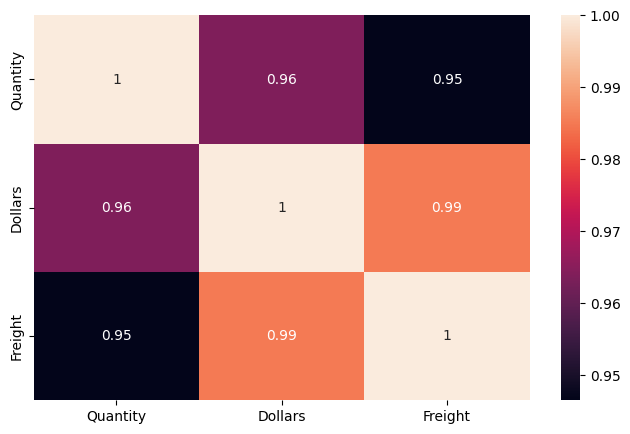

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(vendor_numerical.corr(),annot=True)
plt.show()

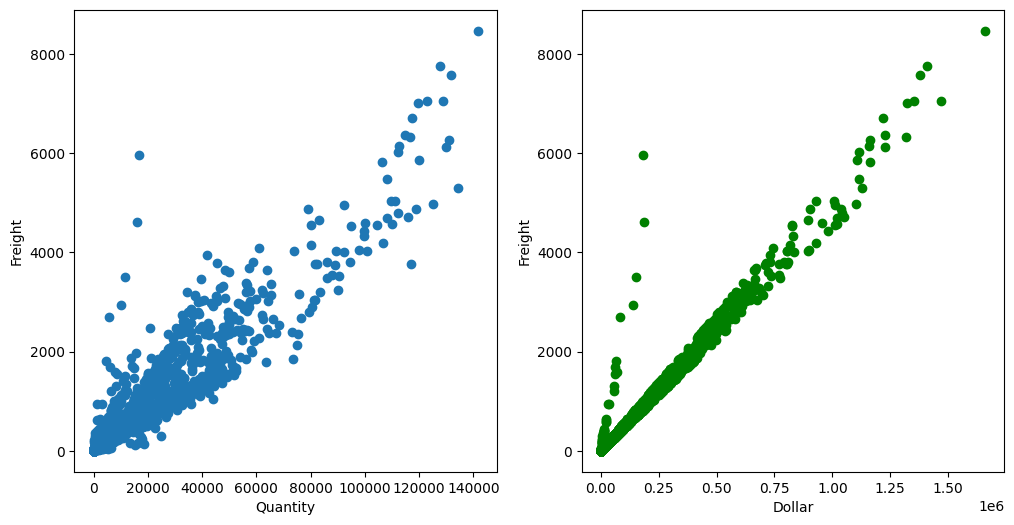

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(vendor_numerical['Quantity'],vendor_numerical['Freight'])
plt.xlabel('Quantity')
plt.ylabel('Freight')
plt.subplot(1,2,2)
plt.scatter(vendor_numerical['Dollars'],vendor_numerical['Freight'],color='green')
plt.xlabel('Dollar')
plt.ylabel('Freight')


plt.show()

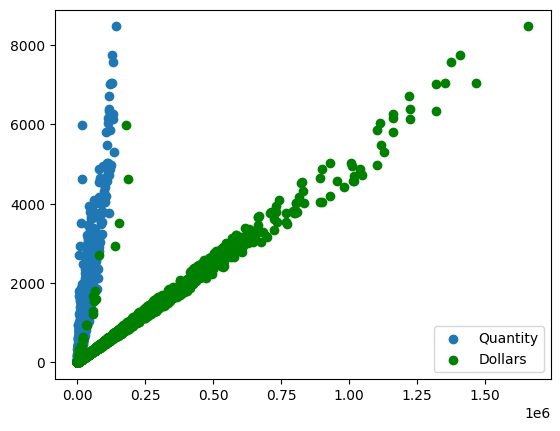

In [13]:
plt.scatter(vendor_numerical['Quantity'],vendor_numerical['Freight'])

plt.scatter(vendor_numerical['Dollars'],vendor_numerical['Freight'],color='green')
plt.legend(['Quantity','Dollars'])
plt.show()

In [14]:
vendor_numerical['Freight_per_unit'] = vendor_numerical['Freight']/vendor_numerical['Quantity']
vendor_numerical.head()

,Quantity,Dollars,Freight,Freight_per_unit
0,6,214.26,3.47,0.578333
1,15,140.55,8.57,0.571333
2,5,106.60,4.61,0.922000
3,10100,137483.78,2935.20,0.290614
4,1935,15527.25,429.20,0.221809


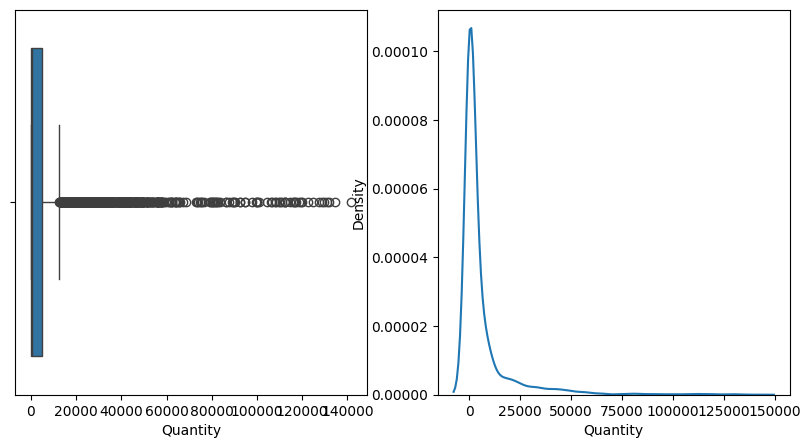

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x=vendor_numerical['Quantity'])
plt.subplot(1,2,2)
sns.kdeplot(vendor_df['Quantity'])
plt.show()

In [16]:
low_qty = vendor_numerical['Quantity'].quantile(0.25)
high_qty = vendor_numerical['Quantity'].quantile(0.75)
print(f"low quantity {low_qty} and high quantity {high_qty} ")

low quantity 83.0 and high quantity 5100.5 


In [17]:
Freightforlowqty = vendor_numerical.loc[vendor_numerical['Quantity'] < low_qty,'Freight_per_unit']

In [18]:
print(f"mean of freight per unit {vendor_numerical['Freight_per_unit'].mean()} and mean of freight for low qty {Freightforlowqty.mean()}")

mean of freight per unit 0.0682416862660074 and mean of freight for low qty 0.09489854253138316


In [19]:
Freightforhighqty = vendor_numerical.loc[vendor_numerical['Quantity'] > high_qty,'Freight_per_unit']

In [20]:
print(f"mean of freight per unit {vendor_numerical['Freight_per_unit'].mean()} and mean of freight for high qty {Freightforhighqty.mean()}")

mean of freight per unit 0.0682416862660074 and mean of freight for high qty 0.049077654690759046


Observation when qty is more the cost per unit is less

In [21]:
outlier_vendor_qty = vendor_numerical.loc[vendor_numerical['Quantity']>(vendor_numerical['Quantity'].quantile(0.75)+3*vendor_numerical['Quantity'].std()),'Quantity']

In [22]:
(outlier_vendor_qty.count()/(vendor_numerical.iloc[:,0].count()))*100

np.float64(2.3994226952913587)

In [23]:
outlier_removed_vendor = vendor_numerical.iloc[vendor_numerical['Quantity']<(vendor_numerical['Quantity'].quantile(0.75)+3*vendor_numerical['Quantity'].std()),:]
outlier_removed_vendor.head()

,Quantity,Dollars,Freight,Freight_per_unit
0,6,214.26,3.47,0.578333
1,15,140.55,8.57,0.571333
2,5,106.60,4.61,0.922000
3,10100,137483.78,2935.20,0.290614
4,1935,15527.25,429.20,0.221809


In [42]:
# X = outlier_removed_vendor[['Quantity','Dollars']]
# Y = outlier_removed_vendor['Freight']
X = vendor_numerical[['Quantity','Dollars']]
Y= vendor_numerical['Freight']

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.8,random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [47]:
lr = LinearRegression()
dtr = DecisionTreeRegressor(random_state=42)
rtr = RandomForestRegressor(random_state=42)
svmr = SVR()

In [48]:
lr.fit(X_train,y_train)
dtr.fit(X_train,y_train)
rtr.fit(X_train,y_train)
svmr.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [49]:
def evaluateModel(model):
    y_pred = model.predict(X_test)
    name = {lr:'LinearRegression',dtr:'DecisionTreeRegressor',rtr:'RandomForestRegressor',svmr:'support vector machine regressor'}
    r2 = r2_score(y_test,y_pred)*100
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)

    print(f"for model {name[model]}")
    print(f"r2 score = {r2} mean absolute error {mae} and mean squared error is {mse}")

In [50]:
models = [lr,dtr,rtr,svmr]
for model in models:
    evaluateModel(model)
    print()

for model LinearRegression
r2 score = 96.64109409533927 mean absolute error 24.380328730862786 and mean squared error is 16850.198721629906

for model DecisionTreeRegressor
r2 score = 95.66147695648787 mean absolute error 29.875162645621952 and mean squared error is 21764.52020883094

for model RandomForestRegressor
r2 score = 96.09650856270642 mean absolute error 27.21793061994158 and mean squared error is 19582.15213332133

for model support vector machine regressor
r2 score = 3.569080809771752 mean absolute error 236.96664129933626 and mean squared error is 483752.8044504436



In [57]:
from sklearn.model_selection import GridSearchCV

params_grid = {'n_estimators':[100,200,300],'max_depth':[1,3,5,7],'min_samples_split':[4,6,10,20],'min_samples_leaf': [1,2,4]}
grid = GridSearchCV(estimator=RandomForestRegressor(),param_grid=params_grid,verbose=1,n_jobs=-1,cv=5,scoring='r2')
grid.fit(X_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [58]:
grid.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 100}

In [59]:
grid.best_score_ * 100

np.float64(97.7984824208195)

In [63]:
Model = RandomForestRegressor(n_estimators=100,max_depth=5,min_samples_leaf=1,min_samples_split=4)
Model.fit(X_train,y_train)
y_pred = Model.predict(X_test)
r2_score(y_test,y_pred)

0.9607316419327135

In [65]:
y_pred_lr = lr.predict(X_test)
r2_score(y_test,y_pred_lr)

0.9664109409533927

In [71]:
input_data = {
     'Quantity':[15,10100],
    'Dollars':[140,137483]
}
unseen = pd.DataFrame(input_data)
Model.predict(unseen)

array([   6.61898022, 2144.57768976])